# **Preprocessor — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.preprocessor import preprocess
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
def run_preprocess_torch(fw="torch", out="numpy", **flags):
    @timer(return_result=True, name = fw + "_" + out)
    def _runner(path_or_img):
        return preprocess(
            path_or_img,
            processor_strategy="torch",
            framework=fw,
            output_format=out,
            layout_name="HWC",
            layout_framework="numpy",
            layout_ensured_name="CHW",
            **flags,
        )
    return _runner

path = images_path[rand]
res_stretch = run_preprocess_torch(stretch=True, normalize=True, local_contrast=False, denoise=True, equalize=False)(path)
res_norm    = run_preprocess_torch(normalize=True)(path)
res_raw     = run_preprocess_torch(normalize=False)(path)

Execution time for 'torch_numpy': 0.867 seconds
Execution time for 'torch_numpy': 0.158 seconds
Execution time for 'torch_numpy': 0.160 seconds


## Visualisation

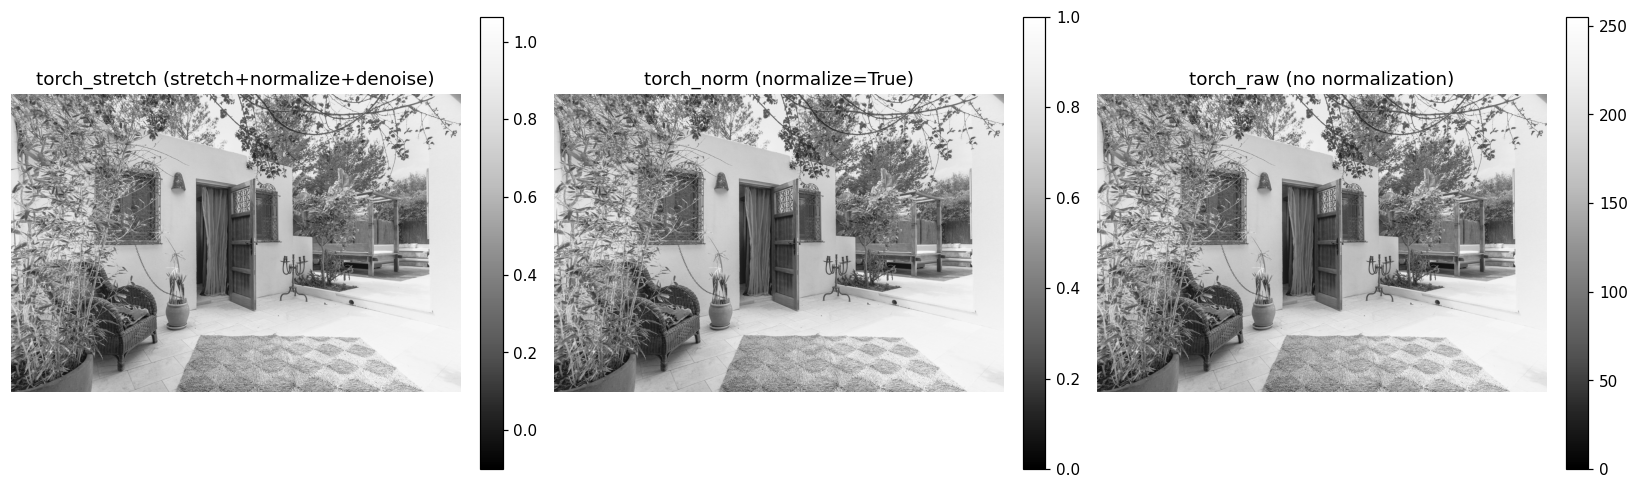

In [5]:
cmap, colorbar = "Greys_r", True
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 9), dpi=110)

show_plane(a, res_stretch[..., 0], title="torch_stretch (stretch+normalize+denoise)", cmap=cmap, colorbar=colorbar)
show_plane(b, res_norm   [..., 0], title="torch_norm (normalize=True)",               cmap=cmap, colorbar=colorbar)
show_plane(c, res_raw    [..., 0], title="torch_raw (no normalization)",              cmap=cmap, colorbar=colorbar)
plt.tight_layout(); plt.show()

## Stats

In [6]:
def stats(x):
    arr = np.asarray(x)
    return float(arr.mean()), float(arr.std()), float(arr.min()), float(arr.max())

def report(name, arr):
    m,s,mi,ma = stats(arr)
    print(f"{name:>24}: mean={m:.5f} | std={s:.5f} | min={mi:.5f} | max={ma:.5f}")

print("— Summary stats —")
report("torch_stretch+norm+denoise", res_stretch)
report("torch_norm",                  res_norm)
report("torch_raw",                   res_raw)

— Summary stats —
torch_stretch+norm+denoise: mean=0.50346 | std=0.28705 | min=-0.10046 | max=1.06393
              torch_norm: mean=0.51866 | std=0.24653 | min=0.00000 | max=1.00000
               torch_raw: mean=132.25791 | std=62.86408 | min=0.00000 | max=255.00000
